Picking up where I left off with the Data Pre Processing Capstone. 


--------- Brief Recap ---------

Dataset covers 20 countries from 2020 - 2025 with a binary target variable (conflict-escalation_6m). EDA raised concerns regarding the variables real-world validity, showing erratic month-to-month behavior and missing major events such as the USA's Jan 6 Insurrection/Riots, while accurately predicting conflicts like the Russia-Ukraine war, a month prior.

Most features are continuous numeric floats with outliers present. Dropped regime_type, election_cycle coumns for unclear or low signal. Dropped political_stability_index due to multicollinearity with instability score. 

Predictive signals identified include arms imports, social media sentiment, and standard economic stress indicators like inflationa and unemployment. 

I added features to the time series dataset which would preserve time-series relationships inside of a classification model. I then split my dataset chronologically, before applying scaling and PCA to reduce dimensionality and run it through a multivariate logistic regression model. 

The model which will serve as a baseline for future modelling efforts showed a impressive class 0 recall, with a much lower class 1 recall. In other words, it wasn't very good at predicting 6m conflict escalations accurately -- which was the entire goal of the model. 

This baseline provides ample opportunity for improvement thorugh more advanced modeling efforts. 

Baseline from Log Regression: 

precision    recall  f1-score   support

           0       0.86      0.92      0.89       250
           1       0.78      0.65      0.71       110

    accuracy                           0.84       360
   macro avg       0.82      0.79      0.80       360
weighted avg       0.84      0.84      0.83       360

[[230  20]
 [ 38  72]]

--------- How I plan to approach this module ---------

I'm going to start with a LightGBM model. Previously reducing all features down to a PCA model and then log regressing didn't provide enough flexibility to catch positives effectively. I'm hoping with a more flexible model, I can better fit for the positives. 



In [13]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [22]:
import os 
import lightgbm
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display
import seaborn as sns
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
    
# reimport treated files from pre processing step 
dataset = pd.read_csv(r"C:\Users\ryan1\Desktop\Capstone Two Project Files\dataset_data_pre_processed.csv")

dataset.head()

,country,month,gdp_growth_pct,inflation_rate,unemployment_rate,food_price_index,energy_dependency_pct,military_expenditure_pct_gdp,arms_imports_index,border_disputes_count,refugee_outflow_thousands,sanctions_active,media_freedom_score,protest_events_last_3m,cyber_attack_incidents,last_conflict_year,trade_dependency_rival_pct,foreign_troops_present,social_media_sentiment,rolling_protest_avg_6m,instability_score,conflict_escalation_6m,arms_imports_index_roll3,arms_imports_index_roll6,arms_imports_index_lag1,arms_imports_index_lag3,gdp_growth_pct_roll3,gdp_growth_pct_roll6,gdp_growth_pct_lag1,gdp_growth_pct_lag3,inflation_rate_roll3,inflation_rate_roll6,inflation_rate_lag1,inflation_rate_lag3,unemployment_rate_roll3,unemployment_rate_roll6,unemployment_rate_lag1,unemployment_rate_lag3,food_price_index_roll3,food_price_index_roll6,food_price_index_lag1,food_price_index_lag3,social_media_sentiment_roll3,social_media_sentiment_roll6,social_media_sentiment_lag1,social_media_sentiment_lag3,years_since_last_conflict,region_Eastern Europe,region_Middle East,region_North America,region_South America,region_South Asia,region_Western Europe
0,Brazil,2020-01-01,3.292274,4.821969,4.291811,105.628769,71.769859,3.089986,92.141774,4,132.543939,0,27.543265,0,13,2014-01-01,29.655392,1,0.279130,2.177743,39.090019,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,False,False,False,True,False,False
1,Brazil,2020-02-01,5.265491,9.813665,0.620002,129.194697,54.527504,1.009883,17.864491,3,151.380973,0,42.125575,8,16,2018-01-01,25.698183,0,0.730459,8.768982,92.156494,1,NaN,NaN,92.141774,NaN,NaN,NaN,3.292274,NaN,NaN,NaN,4.821969,NaN,NaN,NaN,4.291811,NaN,NaN,NaN,105.628769,NaN,NaN,NaN,0.279130,NaN,2,False,False,False,True,False,False
2,Brazil,2020-03-01,-0.974037,10.701998,6.914191,130.586562,39.088637,3.652373,51.928079,2,153.135730,0,84.333469,1,14,2018-01-01,11.518326,0,0.541363,2.242119,64.168321,0,53.978115,NaN,17.864491,NaN,2.527909,NaN,5.265491,NaN,8.445877,NaN,9.813665,NaN,3.942001,NaN,0.620002,NaN,121.803343,NaN,129.194697,NaN,0.516984,NaN,0.730459,NaN,2,False,False,False,True,False,False
3,Brazil,2020-04-01,-1.595410,10.456867,12.601752,146.127866,93.185635,1.480844,31.218015,2,16.774349,0,25.417723,15,15,2018-01-01,20.570074,0,-0.956771,15.218694,124.992587,1,33.670195,NaN,51.928079,92.141774,0.898681,NaN,-0.974037,3.292274,10.324177,NaN,10.701998,4.821969,6.711981,NaN,6.914191,4.291811,135.303042,NaN,130.586562,105.628769,0.105017,NaN,0.541363,0.279130,2,False,False,False,True,False,False
4,Brazil,2020-05-01,0.313102,6.699544,8.975298,99.876591,14.000469,4.088039,28.890343,3,211.967334,0,79.535580,4,9,2018-01-01,16.016826,1,-0.420020,1.643895,58.845819,0,37.345479,NaN,31.218015,17.864491,-0.752115,NaN,-1.595410,5.265491,9.286136,NaN,10.456867,9.813665,9.497080,NaN,12.601752,0.620002,125.530340,NaN,146.127866,129.194697,-0.278476,NaN,-0.956771,0.730459,2,False,False,False,True,False,False


In [17]:
#preprocessing
dataset = dataset.drop(columns=['country', 'last_conflict_year'])

train = dataset[dataset['month'] < '2024-01-01']
test = dataset[dataset['month'] >= '2024-01-01']

train = train.drop(columns=['month'])
test = test.drop(columns=['month'])

X_train = train.drop(columns=['conflict_escalation_6m'])
y_train = train['conflict_escalation_6m']

X_test = test.drop(columns=['conflict_escalation_6m'])
y_test = test['conflict_escalation_6m']

X_train = X_train.dropna()
y_train = y_train[X_train.index]

X_test = X_test.dropna()
y_test = y_test[X_test.index]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 271, number of negative: 589
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000700 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9504
[LightGBM] [Info] Number of data points in the train set: 860, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

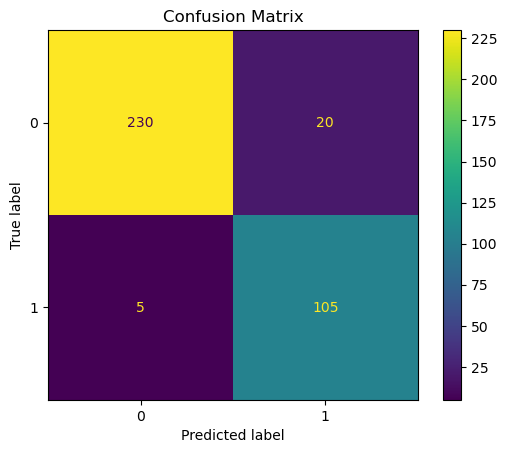

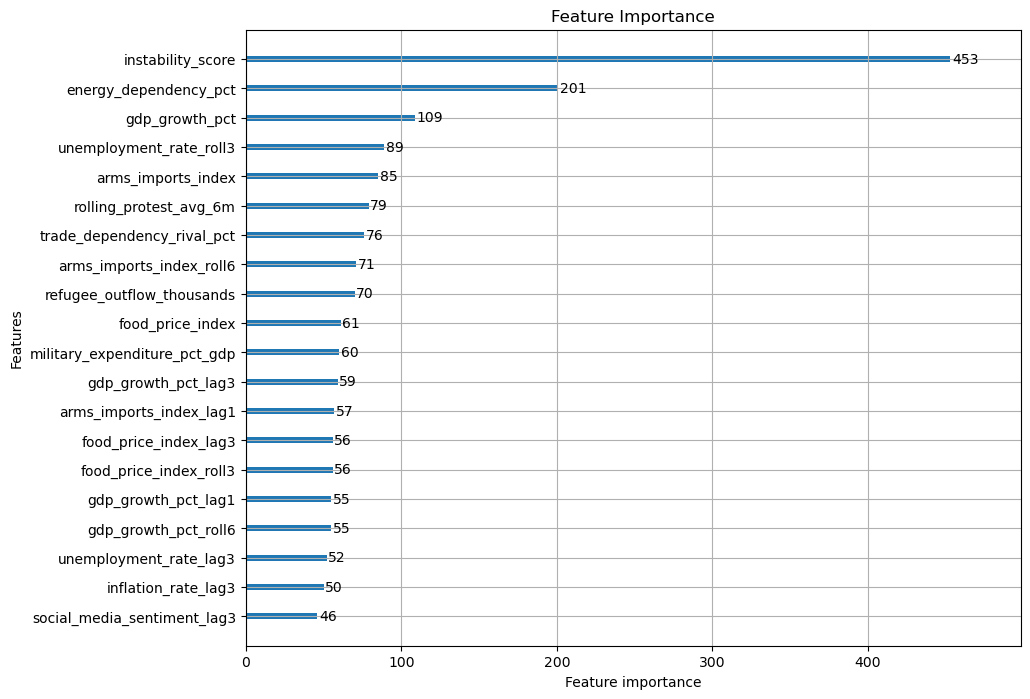

In [ ]:
model = LGBMClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

lgb.plot_importance(model, max_num_features=20, figsize=(10, 8))
plt.title("Feature Importance")
plt.show()

Already a huge improvement over the PCA/LogReg method. I'm going to attempt a little bit of hyperparameter tuning here. 

In [20]:
params = {
    'num_leaves': [20, 31, 50, 80],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 500],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'scale_pos_weight': [1, 2, 3, 5]
}

search = RandomizedSearchCV(
    LGBMClassifier(random_state=42),
    params, n_iter=50, cv=5,
    scoring='f1', random_state=42
)
search.fit(X_train, y_train)
print(search.best_params_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 216, number of negative: 472
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000624 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8571
[LightGBM] [Info] Number of data points in the train set: 688, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.313953 -> initscore=-0.781701
[LightGBM] [Info] Start training from score -0.781701
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 271, number of negative: 589
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000745 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9504
[LightGBM] [Info] Number of data points in the train set: 860, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

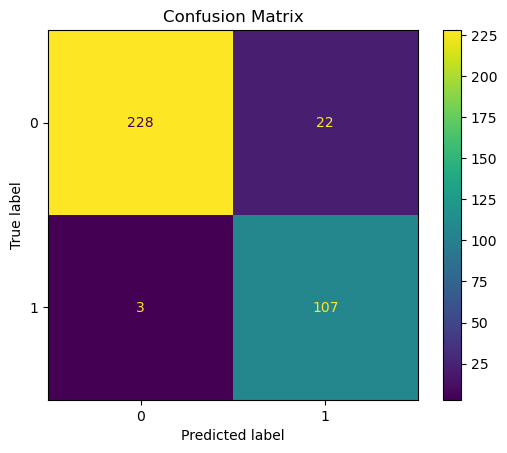

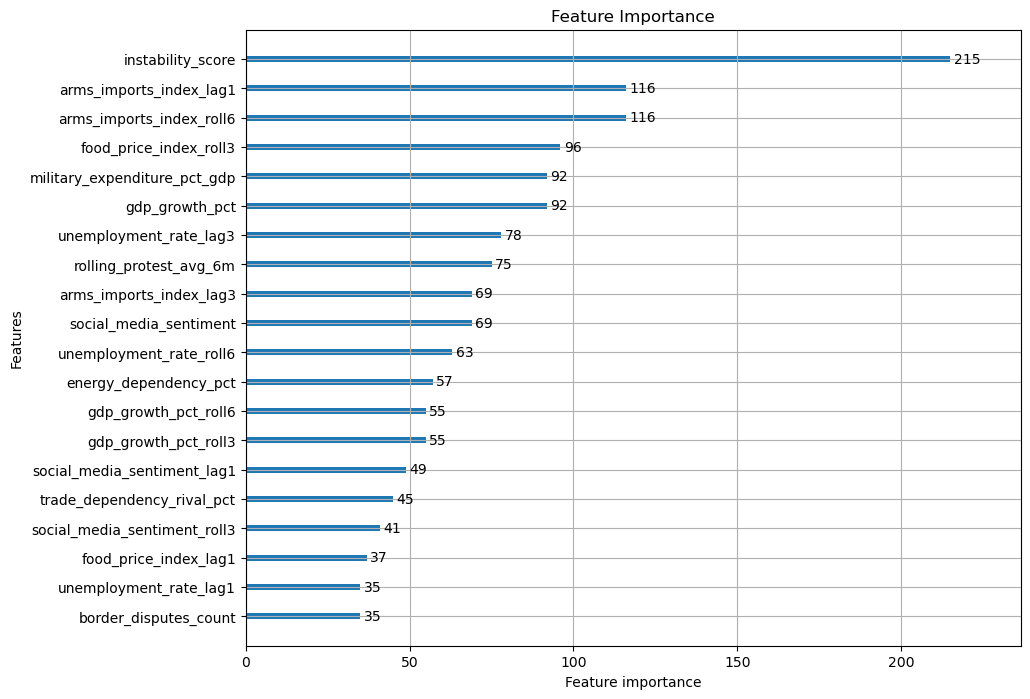

In [ ]:
#Applying best params to model 
model = LGBMClassifier(subsample=0.8, scale_pos_weight=2, num_leaves=80, n_estimators=100, learning_rate=0.01, colsample_bytree=1.0, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

lgb.plot_importance(model, max_num_features=20, figsize=(10, 8))
plt.title("Feature Importance")
plt.show()

Interesting. So with the gradient boosting method and hyperparameter tuning, the best accuracy I seem to be able to get is a model that predicts the 6m conflict escalation feature turning on accurately 83% of the time, but it catches 97% of all 6 m conflict escalations. This implies a decent chunk of false positives in this model. I may try one more model which airs on the side of caution to avoid false positives, even though in this instance, a false positive is probably preferably to a false negative. 

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       250
           1       0.75      0.75      0.75       110

    accuracy                           0.85       360
   macro avg       0.82      0.82      0.82       360
weighted avg       0.85      0.85      0.85       360



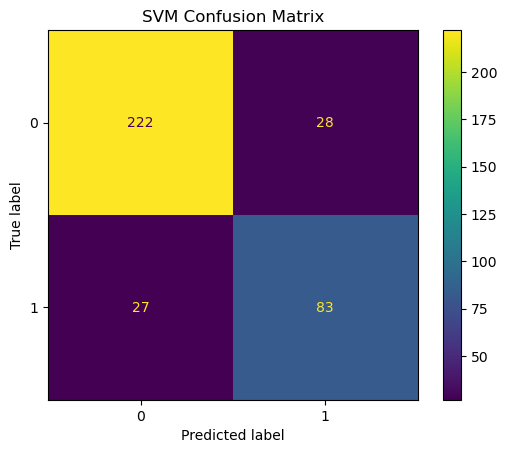

In [ ]:
#pipeline
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42))
])

svm_pipeline.fit(X_train, y_train)

y_pred = svm_pipeline.predict(X_test)


print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("SVM Confusion Matrix")
plt.show()

In [24]:
param_dist = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'svm__kernel': ['rbf', 'linear', 'poly'],
    'svm__class_weight': ['balanced', None]
}

search = RandomizedSearchCV(
    svm_pipeline,
    param_dist,
    n_iter=30,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best F1:", search.best_score_)

# Evaluate best model
y_pred = search.predict(X_test)
print(classification_report(y_test, y_pred))

Best params: {'svm__kernel': 'linear', 'svm__gamma': 'auto', 'svm__class_weight': 'balanced', 'svm__C': 10}
Best F1: 0.8520831581107158
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       250
           1       0.79      0.87      0.83       110

    accuracy                           0.89       360
   macro avg       0.87      0.89      0.88       360
weighted avg       0.90      0.89      0.89       360



It would appear that the LightGBM model with hyperparameter tuning apply is going to most accurately predict when a country is likely to be flagged as a 6m conflict escalation risk. 

It is worth mentioning that the practical application of this model is spurious as we discovered in EDA that the accuracy of the 6m conflict escalation metric was at the very least vague, but at the worst, not very good at actually predicting real-world escalations. 